### Nigerian Ministry of Education - Student Performance Analysis

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Load and Inspect the Data

In [41]:
df = pd.read_csv("../../data/students.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (2400, 38)

First 5 rows:
        student_id first_name middle_name last_name gender date_of_birth  \
0  ALA-20240729001     Obinna         NaN    Okafor      M    2010-06-15   
1  ALA-20240712002    Kelechi       Bello      Musa      M    2008-01-20   
2  ALA-20240809003   Temitope         NaN     Nwosu      M    2010-02-22   
3  ALA-20240818004     Adaeze     Abiodun   Ibrahim      F    2008-12-03   
4  ALA-20240801005      Nneka         NaN  Obasanjo      F    2010-04-20   

  admission_date  class_level study_group  attendance  ...  Chemistry  \
0     2024-07-29           10     Science        90.1  ...      100.0   
1     2024-07-12           10        Arts        92.1  ...        NaN   
2     2024-08-09           10     Science        91.1  ...       21.0   
3     2024-08-18           10        Arts        87.9  ...        NaN   
4     2024-08-01           10     Science        88.5  ...       73.0   

   Further Mathematics Civic Education Computer Science Hausa  

### Step 2: Data Cleaning and Preparation

In [42]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
student_id                  0
first_name                  0
middle_name               764
last_name                   0
gender                      0
date_of_birth               0
admission_date              0
class_level                 0
study_group                 0
attendance                  0
disciplinary_count          0
suspension_count            0
family_income_level         0
daily_study_hours           0
daily_gaming_hours          0
computers_at_home           0
smartphone                  0
has_job                     0
mother_occupation           0
father_occupation           0
Agriculture                 0
Geography                1159
French                   2089
Economics                1241
Biology                  1159
Igbo                     2078
History                  1241
Physics                  1159
Chemistry                1159
Further Mathematics      1159
Civic Education          1241
Computer Science         1159
Hausa                   

In [43]:
class_level_map = {
    10: "SS1",
    11: "SS2",
    12: "SS3"
}

df["class_level"] = df["class_level"].replace(class_level_map)

df.rename(
    columns={
        "Further Mathematics": "further_mathematics",
        "Civic Education": "civic_education",
        "Computer Science": "computer_science",
        "English Language": "english_language",
        "Literature in English": "literature_in_english",
        "Mathematics": "mathematics",
        "Biology": "biology",
        "Physics": "physics",
        "Agriculture": "agriculture",
        "Geography": "geography",
        "French": "french",
        "History": "history",
        "Hausa": "hausa",
        "Igbo": "igbo",
        "Chemistry": "chemistry",
        "Economics": "economics",
        "Government": "government",
        "Yoruba": "yoruba",

    },
    inplace=True,
)

# Define a preferred order for income levels (low -> high)
income_order = ["Low", "Lower Middle", "Upper Middle", "High"]

# Convert data in family_income_level column to an order Categorical so plots sort correctly
df["family_income_level"] = pd.Categorical(df["family_income_level"], categories=income_order, ordered=True)

# Define the correct order for study hours (low -> high)
study_hours_order = ["0-1 Hour", "1-2 Hours", "2-3 Hours", "More than 3 hours"]

df["daily_study_hours"] = pd.Categorical(df["daily_study_hours"], categories=study_hours_order, ordered=True)

# print("\nIncome level value counts:")
# print(df["family_income_level"].value_counts())
#
# print("")
#
# print("\nDaily study hours value counts:")
# print(df["daily_study_hours"].value_counts())


### Task 1: Violin Plots:

Mathematics and English Languae scores by family income level

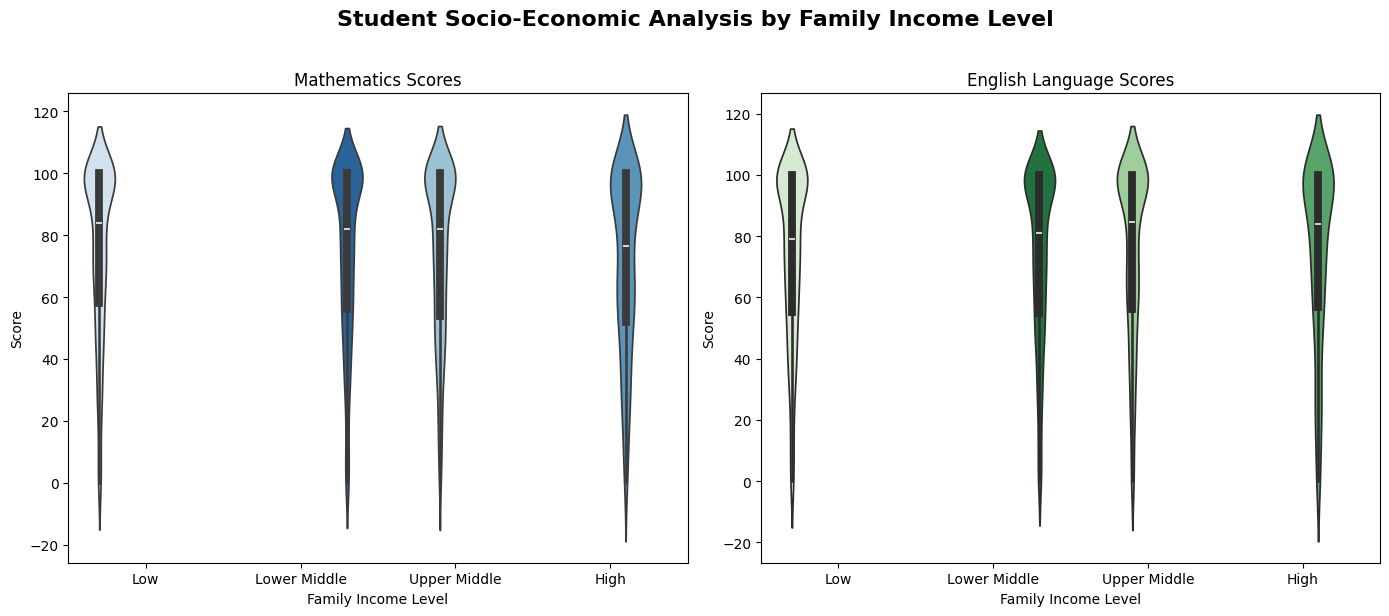

In [44]:
# Drop rows where Maths or English score is missing
violin_df = df.dropna(subset=["mathematics", "english_language"])

# Create a figure with two (2) subplots (violin plots, side-by-sde)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
fig.suptitle("Student Socio-Economic Analysis by Family Income Level", fontsize=16, fontweight="bold", y=1.02)

# Left plot: Mathematics
sns.violinplot(
    data=violin_df,
    x="family_income_level",
    y="mathematics",
    ax=axes[0],
    hue="family_income_level",
    order=income_order,
    legend=False,
    palette="Blues",
    inner="box",
)

axes[0].set_title("Mathematics Scores")
axes[0].set_xlabel("Family Income Level")
axes[0].set_ylabel("Score")
# axes[0].tick_params(axis="x", rotation=15)


# Right plot: English Language
sns.violinplot(
    data=violin_df,
    x="family_income_level",
    y="english_language",
    ax=axes[1],
    hue="family_income_level",
    order=income_order,
    legend=False,
    palette="Greens",
    inner="box",
)

axes[1].set_title("English Language Scores")
axes[1].set_xlabel("Family Income Level")
axes[1].set_ylabel("Score")
# axes[0].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("students_socioeconomic_analysis_violinplot.png", dpi=300, bbox_inches="tight") #dpi = 30  - means high resoultion.....bbox_inches="tight" - means trim whitespace
plt.show()


Task 2 : Pair Plot - Analyze relationship between subject scores split by gender.

Relationships between core subject scores colored by gender

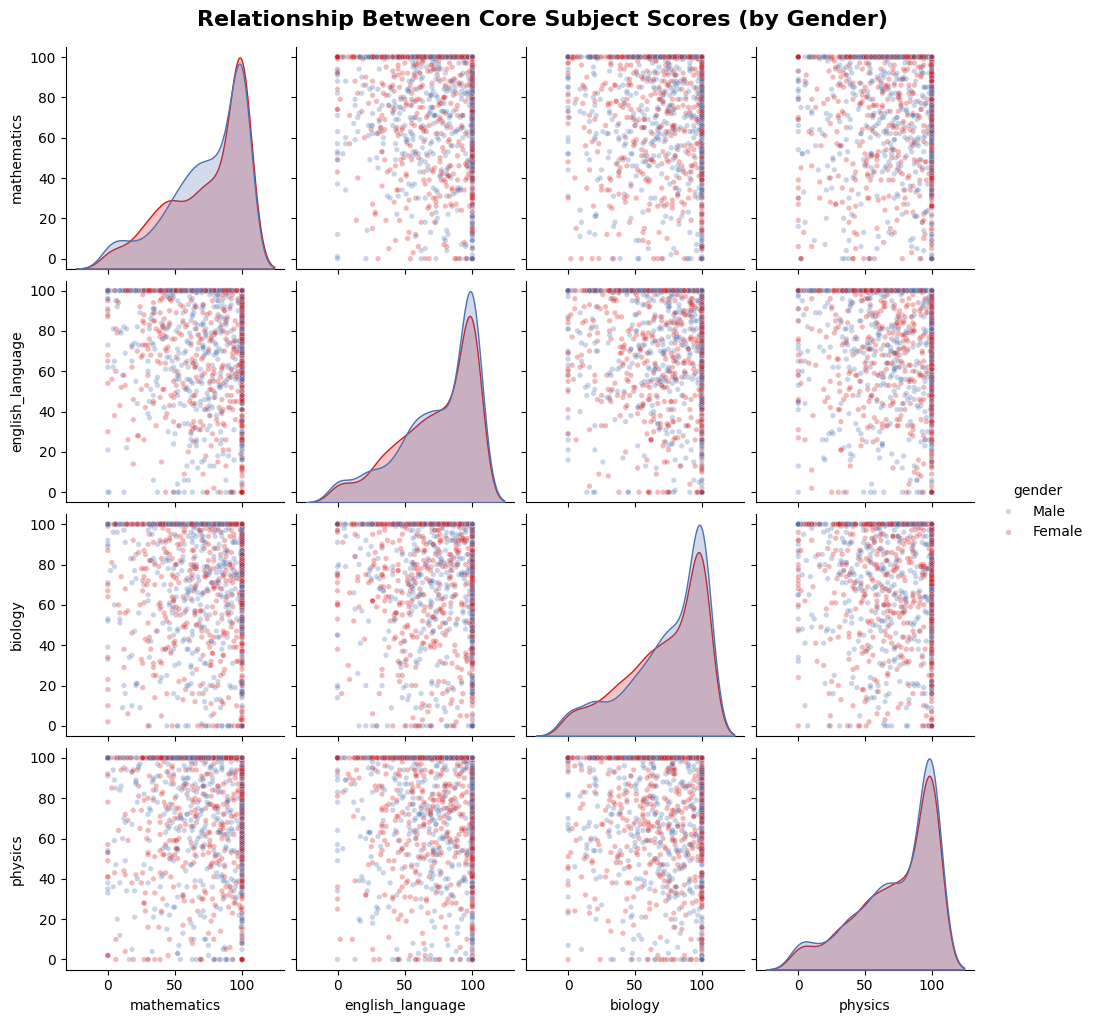

In [ ]:
core_subjects = ["mathematics", "english_language", "biology", "physics"]
all_columns = core_subjects + ["gender"]

pair_df = df.dropna(subset=all_columns)  #drop ros where any of these columns are missing * pair plots doesnt handle missing values well.

# Map gender codes to readable labels
pair_df = pair_df.copy()   #create a  sfe copy
pair_df["gender"] = pair_df["gender"].map({  # this will make the legend redable and better for presentation
    "M": "Male",
    "F": "Female",
})

# Build the pair plot
pair_plot = sns.pairplot(  #builds the pair plot - create a grid of plots.
    pair_df[all_columns],   # this is the key input
    hue="gender",   # color points by gender
    palette={ "Male": "#4c72b0", "Female": "#d7191c" },
    plot_kws={"alpha": 0.3, "s": 15},  # alpha-0.3 - transparency (reduces clutter). s=15 - point size -- this helps when many points overlap.
    diag_kind="kde", - on diagonal - smooth distribution curve
)

pair_plot.fig.suptitle("Relationship Between Core Subject Scores (by Gender)", fontsize=16, fontweight="bold", y=1.02)
pair_plot.savefig("pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 3: 
Correlation Heat Map

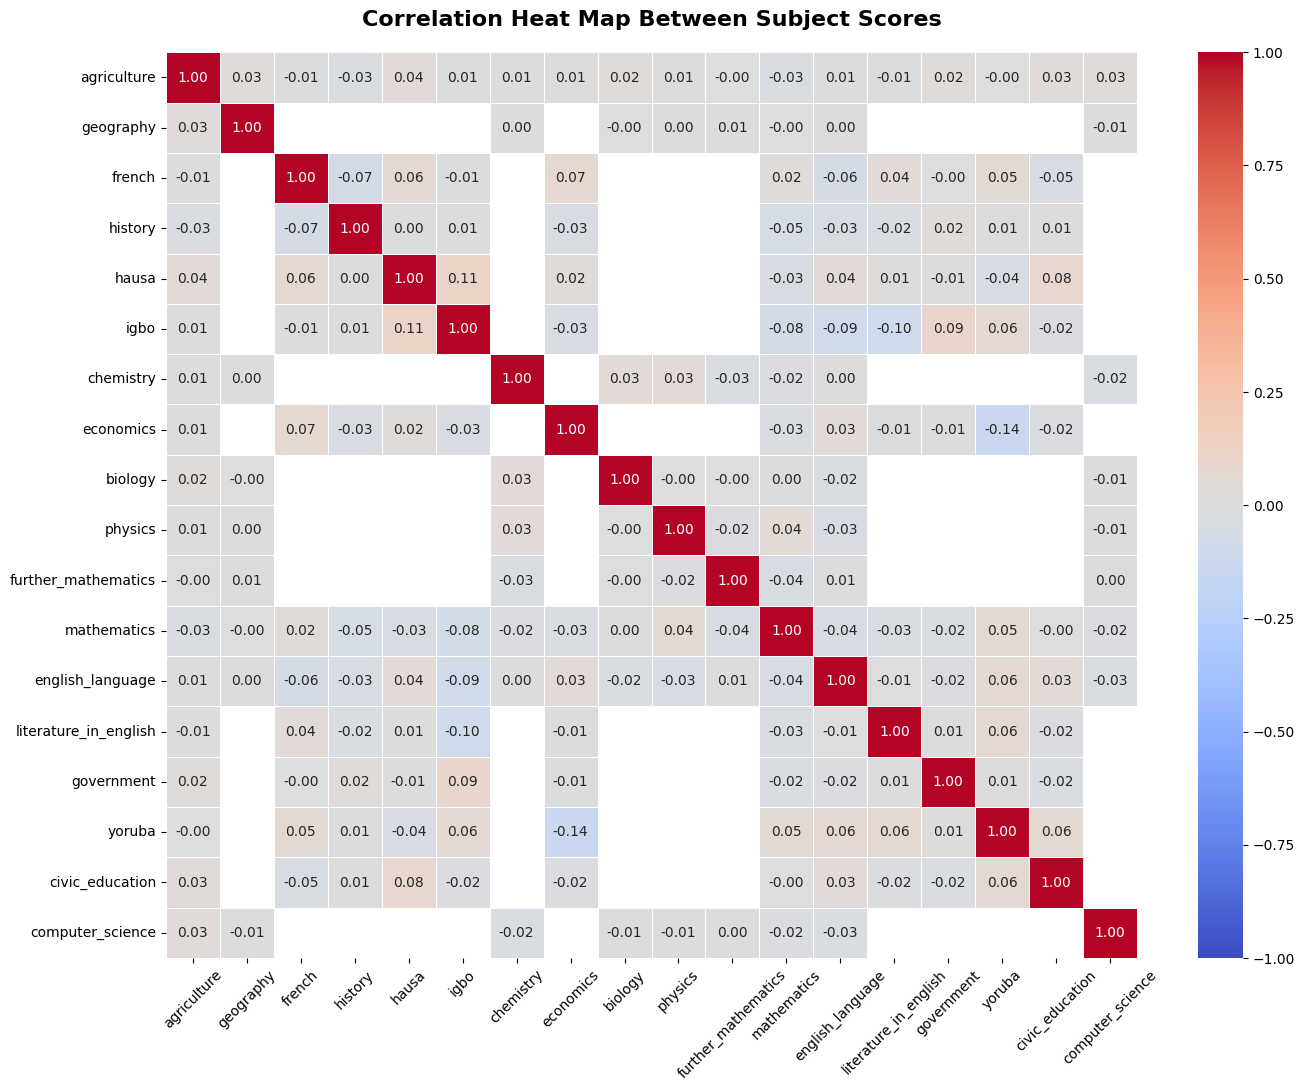

In [46]:
# Select all subject score colums
subject_columns = [
    "agriculture", "geography", "french", "history", "hausa", "igbo", "chemistry", "economics", "biology",
    "physics", "further_mathematics", "mathematics", "english_language", "literature_in_english",
    "government", "yoruba", "civic_education", "computer_science"
]

# Compute the correlation matrix (ignores NaN automatically) # You isolate only numeric score columns → required for correlation - if non-numeroc columns are included - .corr() would fail/ignore them
corr_matrix = df[subject_columns].corr()  #selects only the df[subject_columns] and computes correlation between each subjects

# What correlation means:
# 1  - Perfect positive
# 0  - No relationship
# -1 - Inverse relationship

# Plot the heatmap
fig, axes = plt.subplots(figsize=(14, 11)) # axes - where th eheatmap will be drawn
sns.heatmap(
    corr_matrix, #pass the correlatiuon matrix into Seaborn
    annot=True,  # show numbers inside each cell
    fmt=".2f",  # format numbers to 2 decimal places
    cmap="coolwarm",
    vmin=-1,  # fix the color scale - ensures consistent interpretation across plots.
    vmax=1,    # fix the color scale - ensures consistent interpretation across plots.
    linewidths=0.5,    # adds spacing between cells
    linecolor="white",  # makes grid lines visible
    ax=axes,     # draw heatmap on chart
)

axes.set_title("Correlation Heat Map Between Subject Scores", fontsize=16, fontweight="bold", y=1.02) # y=1.02 - moves title slightly upward
axes.tick_params(axis="x", rotation=45)  # Rotate x-axis lable- this prevents overlapping

plt.tight_layout()  # this prevents overlapping labels/clipped text
plt.savefig("corr_heatmap_subject_scores.png", dpi=300, bbox_inches="tight")  # bbox_inches="tight"- trims extra white space
plt.show()   # display the chart

### Task 4
Bar Plots - Students performance analysis based on Three (3) Factor

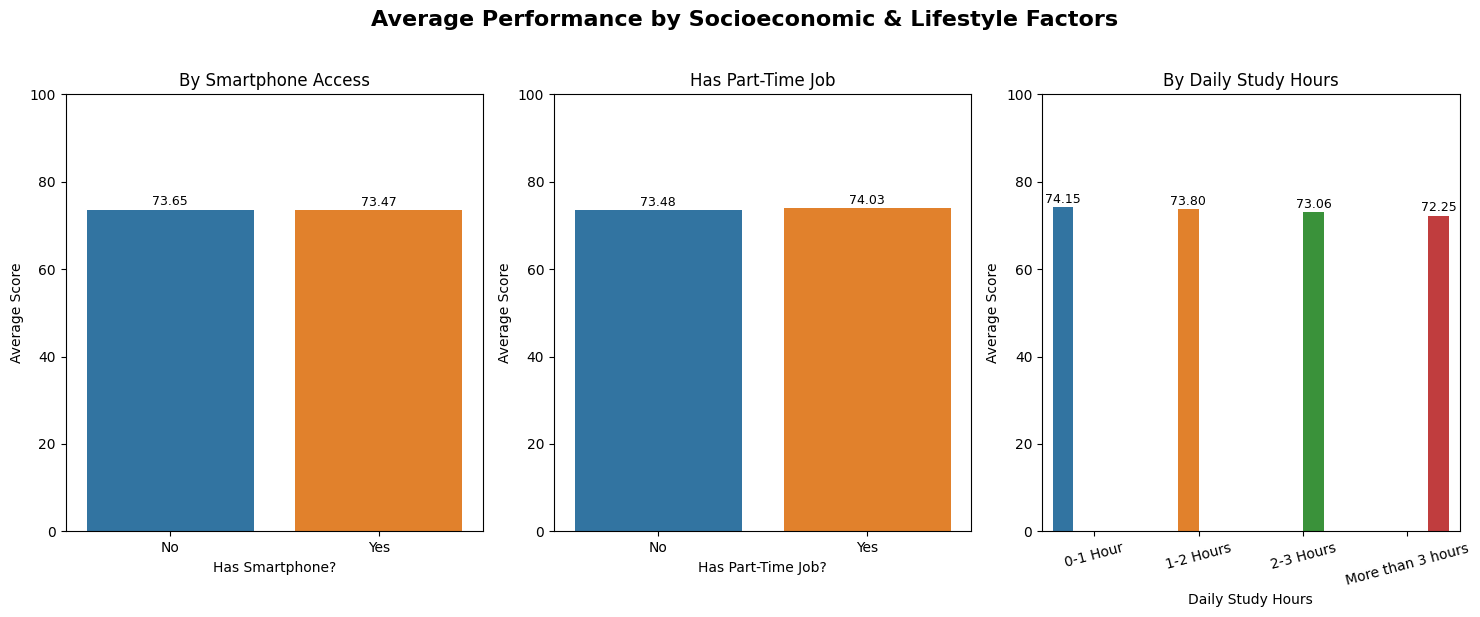

In [47]:
# Make a bar plot showing performance differences based on:
#     - Whether students have a smartphone
#     - Whether students have a part-time job
#     - Daily study hours category

df["average_score"] = df[subject_columns].mean(axis=1) #axis = 1 - means across rows, df["average_score"] create a  new column -- this if ofr each student

# 4a - Smartphone access
smartphone_avg = (df.dropna(subset=["average_score", "smartphone"]) # subset - means only look at speciific columns having missing (focus only on these columns)
                        .groupby("smartphone")["average_score"] # Split data into groups by smartphone then from each group, select the average_score column.
                        .mean()
                        .reset_index()
)

# 4b - Has job
has_job_avg = (
    df.dropna(subset=["average_score", "has_job"])
            .groupby("has_job")["average_score"] 
            .mean()
            .reset_index()
)

# 4c - Daily Study Hours
daily_study_avg = (
    df.dropna(subset=["average_score", "daily_study_hours"])
            .groupby("daily_study_hours", observed=True)["average_score"] #observed - true - means only include categories that actually exist in data
            .mean()
            .reset_index()
)

# Build a figure with three bar plots side by side
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6)) # create 3 plots side by side
fig.suptitle("Average Performance by Socioeconomic & Lifestyle Factors", fontsize=16, fontweight="bold", y=1.02)

#The function below adds numbers on top of the bars.
def add_bar_label(ax: plt.Axes): #it takes one input the "ax" = the chart (Axes object), ply.Axes (the ax is expected to be a Matplotlib Axes (a chart) )
    for bar in ax.patches: # ax.patches is a list of all the bars (rectangles) in the chart . So loop through each bar, 
        height = bar.get_height() #get the height of each bar i.e value of each bar (in this case average_score)

        ax.text(  #this function places text on the chart/bar
            bar.get_x() + bar.get_width() / 2, # bar.get_x() - left edge of bar, bar.get_width() - width of bar , /2 - center of bar.(Place text at the center of the bar (horizontally))
            height + 0.3,  #Place text slightly above the bar (without this text overlaps the bar)
            f"{height:.2f}", #format the height value to 2 decimal places
            ha="center", # center the text horizontally
            va="bottom",  #anchor the text from the bottom
            fontsize=9,  # make text readbale but not too large
        )

#The function above can also be written as simple as the function below.. it's Matplotlib's built in ax.bar_label()
# for ax in axes:
#     for conatiner in ax.containers:
#         ax.bar_label(conatiner, fmt="%.2f")

# Smartphone bar chart
sns.barplot(
    data=smartphone_avg,
    x="smartphone", 
    y="average_score",
    hue="smartphone",
    legend=False,
    ax=axes[0],
)

axes[0].set_title("By Smartphone Access")
axes[0].set_xlabel("Has Smartphone?")
axes[0].set_ylabel("Average Score")
axes[0].set_ylim(0, 100)
add_bar_label(axes[0])


# "Has Job" bar chart
sns.barplot(
    data=has_job_avg,
    x="has_job",
    y="average_score",
    hue="has_job",
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Has Part-Time Job")
axes[1].set_xlabel("Has Part-Time Job?")
axes[1].set_ylabel("Average Score")
axes[1].set_ylim(0, 100)
add_bar_label(axes[1])

# "Daily Study Hours" bar chart
sns.barplot(
    data=daily_study_avg,
    x="daily_study_hours",
    y="average_score",
    hue="daily_study_hours",
    legend=False,
    ax=axes[2],
    order=study_hours_order,
)

axes[2].set_title("By Daily Study Hours")
axes[2].set_xlabel("Daily Study Hours")
axes[2].set_ylabel("Average Score")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis="x", rotation=15) #this prevents label overlap
add_bar_label(axes[2])

plt.tight_layout() #fix spacing
plt.savefig("avg_performance.png", dpi=300, bbox_inches="tight")
plt.show()